In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
path = '/home/dacslab/lasse_jantsch/circuit_discovery/'
if path not in sys.path:
    sys.path.insert(0, path)

PLOT_DIR = './plots'

import torch
from torch.utils.data import DataLoader, Dataset
import numpy as np

# from nnsight import  NNsight, LanguageModel
from transformers import AutoTokenizer, AutoConfig, AutoModelForCausalLM
from datasets import load_dataset

from nnsight import NNsight

from experiments.mib.data_utils import MIBDataset

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

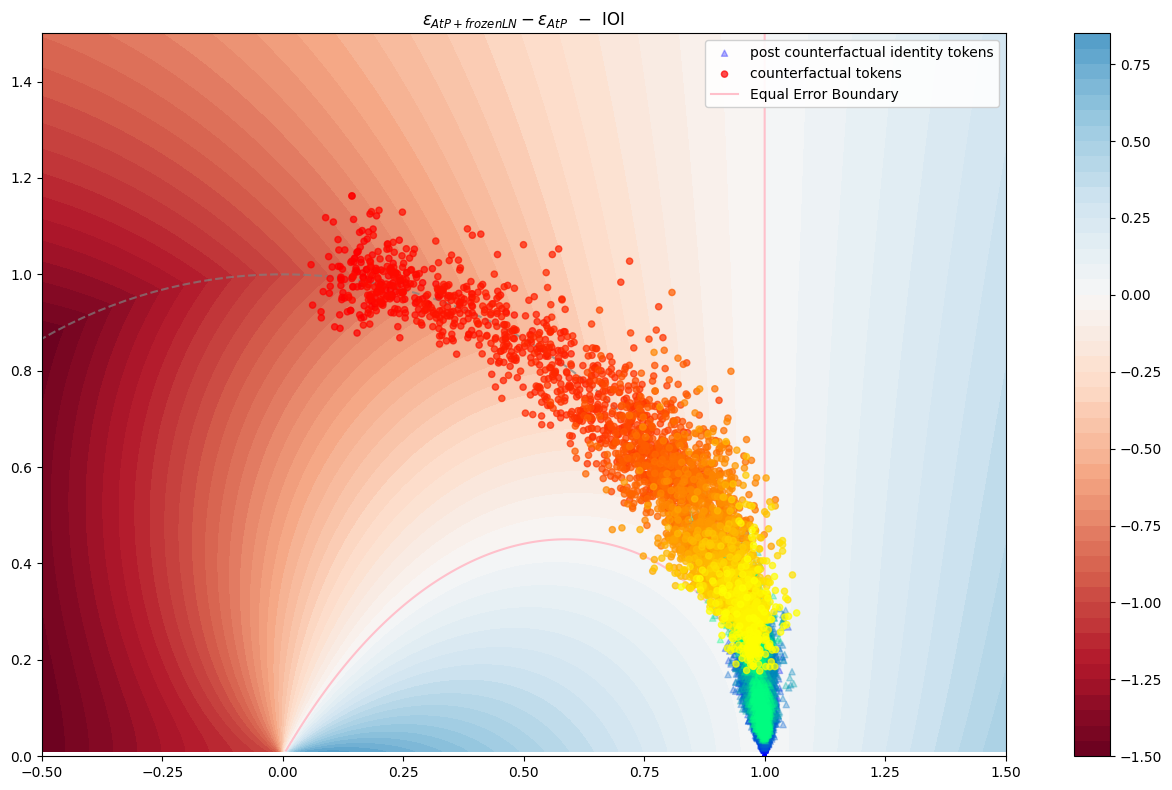

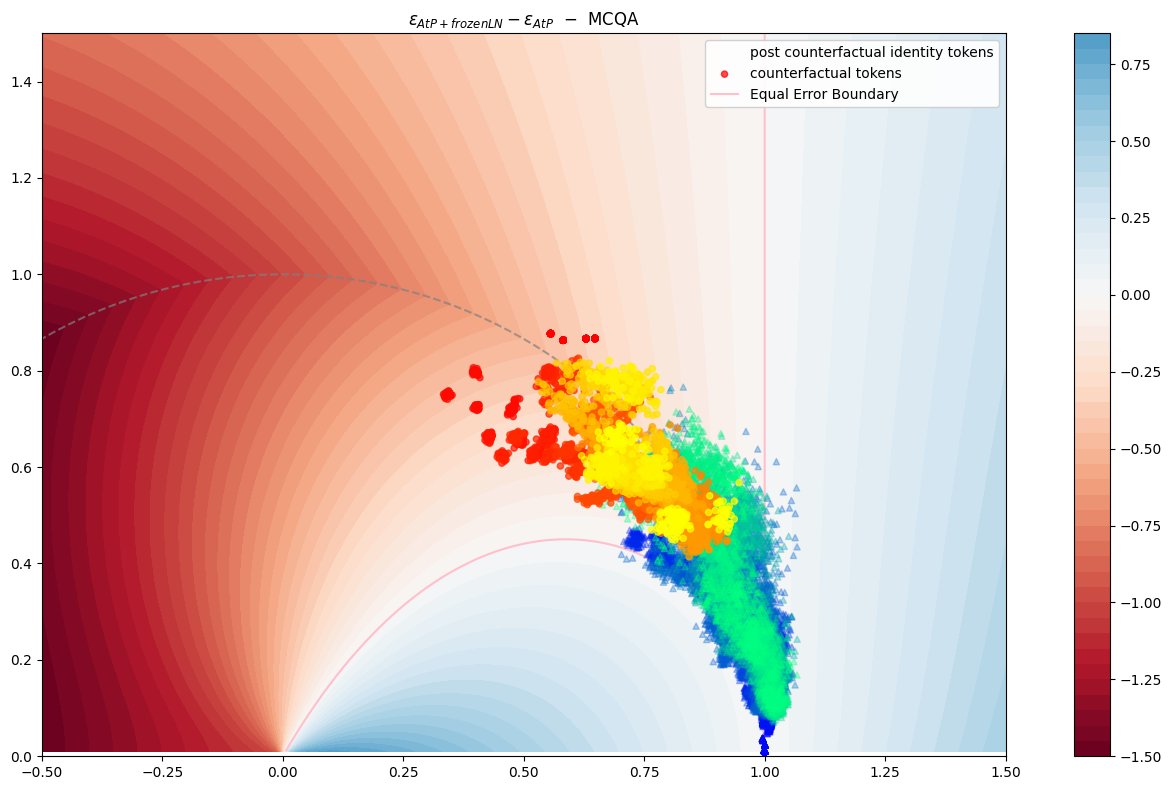

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

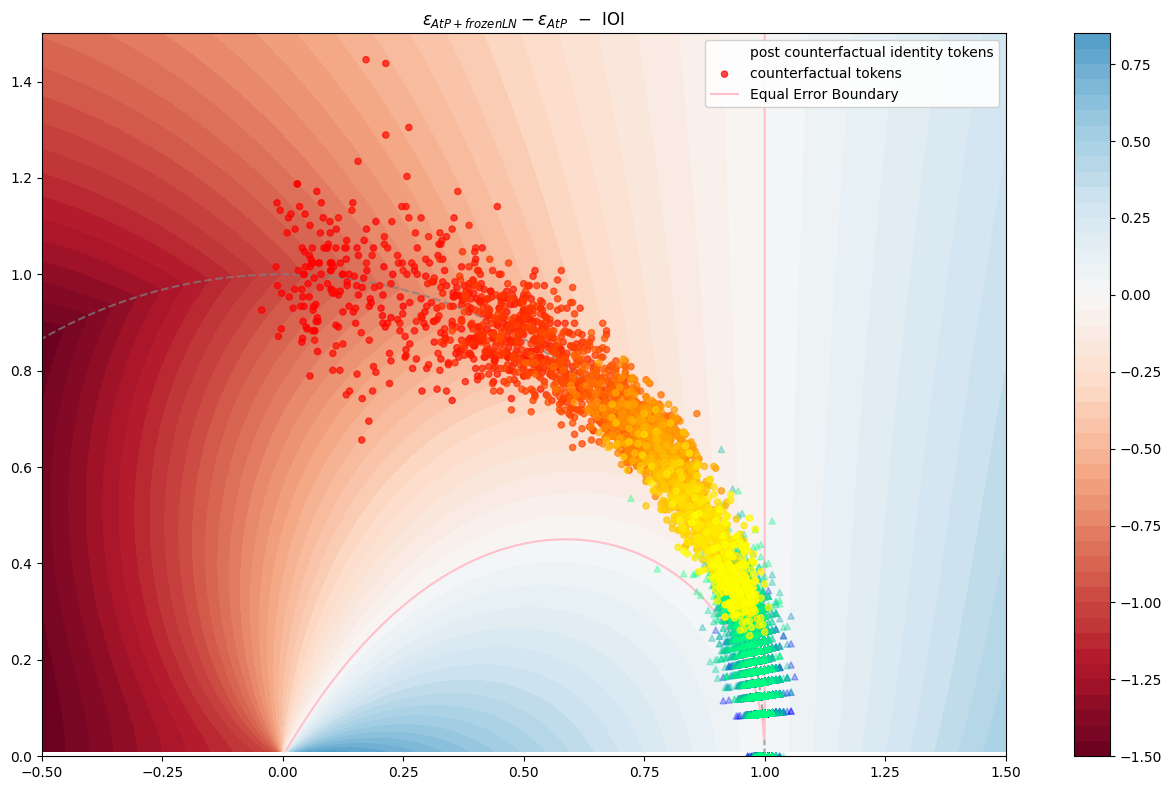

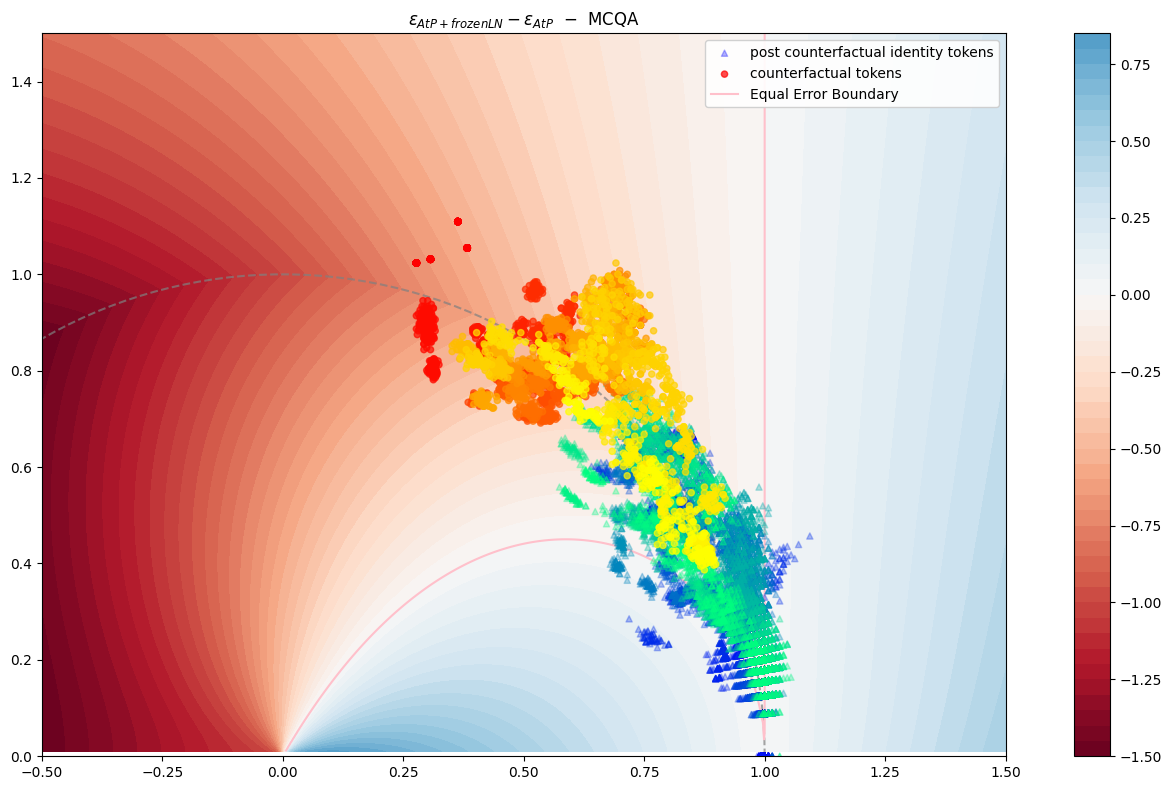

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

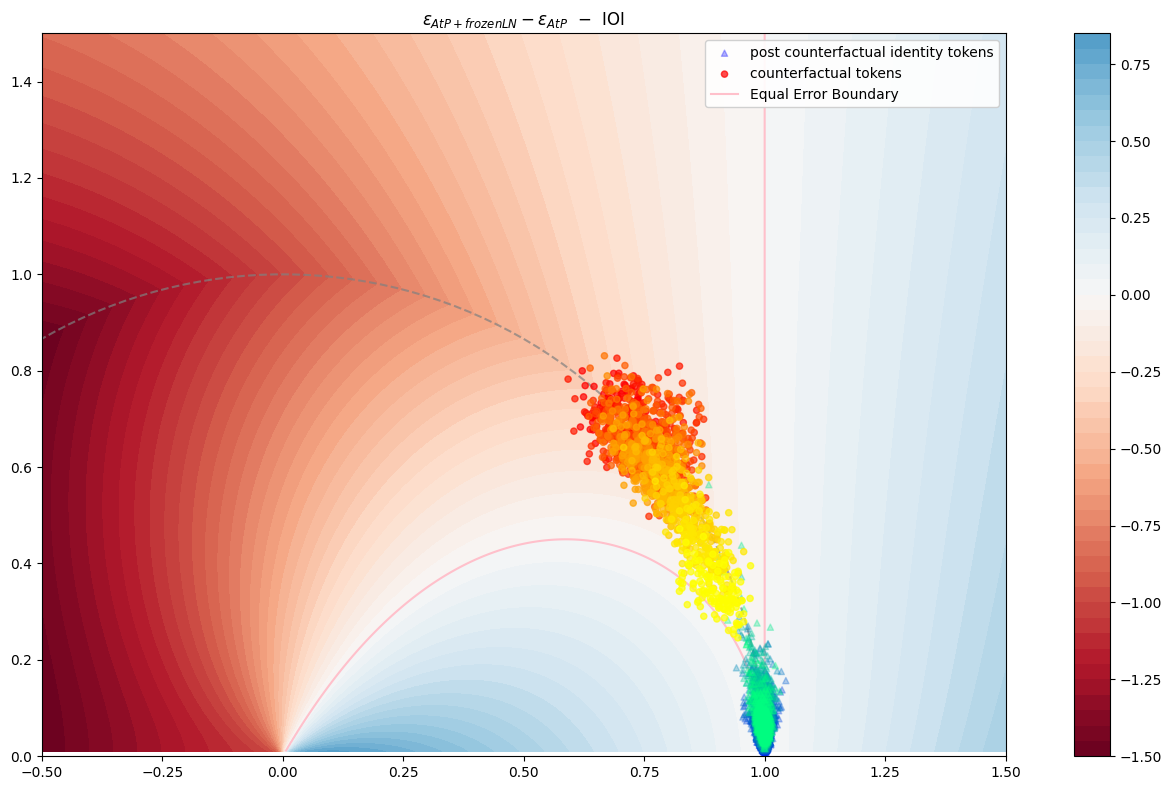

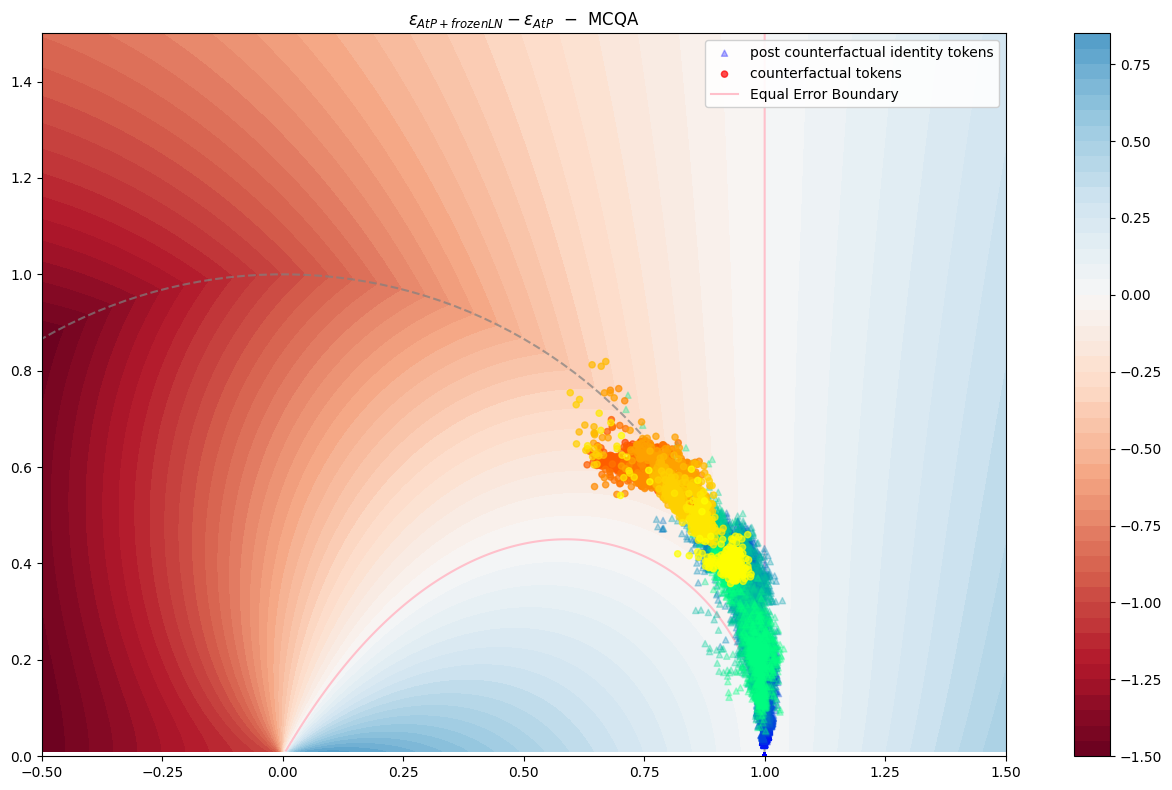

In [32]:
model_id = 'google/gemma-2-2b'
model_id = 'Qwen/Qwen2.5-0.5B'
model_id = 'gpt2'

task = 'ioi'
task = 'mcqa'

for model_id in ['google/gemma-2-2b', 'Qwen/Qwen2.5-0.5B', 'gpt2']:

    model = AutoModelForCausalLM.from_pretrained(model_id, attn_implementation="eager", device_map='auto').eval()

    tokenizer = AutoTokenizer.from_pretrained(model_id)
    tokenizer.padding_side = 'left'
    if model_id == 'gpt2':
        tokenizer.padding_side == 'right'
    if not tokenizer.pad_token:
        tokenizer.pad_token = tokenizer.eos_token
        
    # model = NNsight(model)
    model = NNsight(model)

    for task in ['ioi', 'mcqa']:

        dataset = MIBDataset(task, tokenizer, model_id, num_examples=None, split='test')
        dl = dataset.dataloader(128)

        clean_prompts, corrupted_prompts = next(iter(dl))[:2]
        inputs = tokenizer(clean_prompts + corrupted_prompts, return_tensors='pt', padding=True)

        B, S = inputs['input_ids'].shape

        non_identity_mask = (inputs['input_ids'][:B//2] != inputs['input_ids'][B//2:])
        first_non_identity = (non_identity_mask).int().argmax(-1)
        post_change_identity_mask = torch.arange(S)[None, :].repeat(B//2, 1) > first_non_identity[:, None]
        post_change_identity_mask[non_identity_mask] = False

        post_change_identity_mask[~inputs['attention_mask'][:B//2].bool()] = False

        id_vals = (non_identity_mask).sum()
        num_values = (non_identity_mask).sum() + (post_change_identity_mask).sum()

        def norm_dif(inputs, return_non_id):
            clean_norms = inputs[:B//2].norm(dim=-1)
            corrupt_norms = inputs[B//2:].norm(dim=-1)

            diff = (clean_norms - corrupt_norms) / clean_norms

            if return_non_id: # mean identity diff
                return diff[non_identity_mask]
            
            return diff[post_change_identity_mask]

        def cos_sim(inputs, return_non_id):
            clean = inputs[:B//2]
            corr = inputs[B//2:]

            sim = torch.cosine_similarity(clean, corr, dim=-1)

            if return_non_id:
                return sim[non_identity_mask]
            
            return sim[post_change_identity_mask]

        if model_id == 'gpt2':
            n_layers = model.config.n_layer
            cache = torch.zeros(12, num_values, 2)

            with torch.no_grad(), model.trace(**inputs) as tracer:
                for i, layer in enumerate(model.transformer.h):
                    residual_pre = layer.ln_1.input
                    sim = cos_sim(residual_pre, True).save()
                    diff = norm_dif(residual_pre, True)
                    scale = (1 - diff)
                    cache[i, :id_vals, 0] = (sim * scale)
                    cache[i, :id_vals, 1] = (1 - sim ** 2).sqrt() * scale

                    sim = cos_sim(residual_pre, False)
                    diff = norm_dif(residual_pre, False)
                    scale = (1 - diff)
                    cache[i, id_vals:, 0] = (sim * scale)
                    cache[i, id_vals:, 1] = (1 - sim ** 2).sqrt() * scale
        else:
            n_layers = model.config.num_hidden_layers
            cache = torch.zeros(n_layers, num_values, 2)


            with torch.no_grad(), model.trace(**inputs) as tracer:
                for i, layer in enumerate(model.model.layers):
                    residual_pre = layer.input_layernorm.input
                    sim = cos_sim(residual_pre, True)
                    diff = norm_dif(residual_pre, True)
                    scale = (1 - diff)
                    cache[i, :id_vals, 0] = (sim * scale).cpu().save()
                    cache[i, :id_vals, 1] = ((1 - sim ** 2).sqrt() * scale).cpu().save()

                    sim = cos_sim(residual_pre, False)
                    diff = norm_dif(residual_pre, False)
                    scale = (1 - diff)
                    cache[i, id_vals:, 0] = (sim * scale).cpu().save()
                    cache[i, id_vals:, 1] = ((1 - sim ** 2).sqrt() * scale).cpu().save()

        import numpy as np
        import matplotlib.pyplot as plt

        x = np.linspace(-0.5, 1.5, 400)
        y = np.linspace(0.01, 1.5, 200)
        X, Y = np.meshgrid(x, y)

        D = np.sqrt(X**2 + Y**2)

        True_X = X / D
        True_Y = Y / D

        AtP_X = np.ones_like(X)
        AtP_Y = Y

        Frozen_X = X
        Frozen_Y = Y

        eps_AtP = np.sqrt((AtP_X - True_X)**2 + (AtP_Y - True_Y)**2)
        eps_FrozenLN = np.abs(D - 1) # Mathematically simplifies to how far the point is from radius 1

        error_diff = eps_FrozenLN - eps_AtP

        fig, ax = plt.subplots(1, 1, figsize=(14, 8))

        # Common function to draw the unit circle for reference
        def draw_unit_circle(ax):
            theta = np.linspace(0, np.pi, 100)
            ax.plot(np.cos(theta), np.sin(theta), color='gray', linestyle='--', alpha=0.7)
            ax.set_xlim(-0.5, 1.5)
            ax.set_ylim(0, 1.5)
            ax.set_aspect('equal')
            
        max_diff = max(abs(np.min(error_diff)), abs(np.max(error_diff)))
        c3 = ax.contourf(X, Y, error_diff, levels=50, cmap='RdBu', vmin=-max_diff, vmax=max_diff)
        ax.set_title(r'$\epsilon_{AtP+frozenLN} - \epsilon_{AtP}$  $-$' + f'  {task.upper()}')
        draw_unit_circle(ax)
        fig.colorbar(c3, ax=ax)

        L = n_layers
        data = cache[:L,].detach().numpy()

        l_indices = np.arange(L)[:, None].repeat(num_values - id_vals).flatten()
        ax.scatter(data[:, id_vals:, 0], data[:, id_vals:, 1], 
                    c=l_indices, cmap='winter', marker='^', s=20, alpha=0.3, zorder=5, label='post counterfactual identity tokens' if ax == ax else "")


        l_indices = np.arange(L)[:, None].repeat(id_vals).flatten()
        ax.scatter(data[:, :id_vals, 0], data[:, :id_vals, 1], 
                    c=l_indices, cmap='autumn', marker='o', s=20, alpha=0.7, zorder=5, label='counterfactual tokens' if ax == ax else "")


        ax.legend(loc='upper left')
        from matplotlib.patches import Ellipse
        import matplotlib.cm as cm
        cmap = cm.spring

        ax.legend(loc='upper left', framealpha=0.9)

        # Plot the Equal Error Boundary Line
        boundary_line = ax.contour(X, Y, error_diff, levels=[0], colors='pink', linewidths=1.5, linestyles='solid')

        # Add a custom legend entry for the boundary line
        ax.plot([], [], color='pink', linewidth=1.5, label='Equal Error Boundary')
        ax.legend(loc='upper right', framealpha=0.9)

        model_str = model_id.split('/')[-1].lower()
        plt.savefig(os.path.join(PLOT_DIR, f'{model_str}_{task}_norm_error_with_samples.png') ,bbox_inches='tight', pad_inches=0.2)

        plt.tight_layout()
        plt.show()


/tmp/ipykernel_3764146/3790229012.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='upper left')


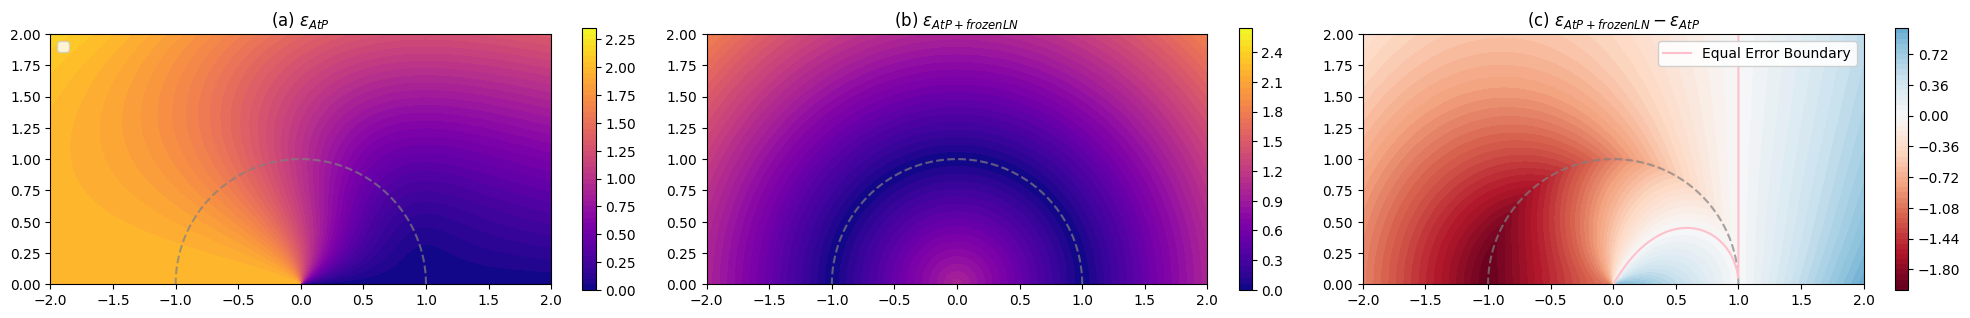

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3.0, 2.0, 400)
y = np.linspace(0.01, 2.0, 200)
X, Y = np.meshgrid(x, y)

D = np.sqrt(X**2 + Y**2)

True_X = X / D
True_Y = Y / D

AtP_X = np.ones_like(X)
AtP_Y = Y

Frozen_X = X
Frozen_Y = Y

eps_AtP = np.sqrt((AtP_X - True_X)**2 + (AtP_Y - True_Y)**2)
eps_FrozenLN = np.abs(D - 1) # Mathematically simplifies to how far the point is from radius 1

error_diff = eps_FrozenLN - eps_AtP

fig, axes = plt.subplots(1, 3, figsize=(20, 3))

# Common function to draw the unit circle for reference
def draw_unit_circle(ax):
    theta = np.linspace(0, np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), color='gray', linestyle='--', alpha=0.7)
    ax.set_xlim(-2, 2)
    ax.set_ylim(0, 2)
    ax.set_aspect('equal')

# Plot (a): Standard AtP Error
c1 = axes[0].contourf(X, Y, eps_AtP, levels=50, cmap='plasma')
axes[0].set_title(r'(a) $\epsilon_{AtP}$')
draw_unit_circle(axes[0])
fig.colorbar(c1, ax=axes[0])

# Plot (b): Frozen LayerNorm Error
c2 = axes[1].contourf(X, Y, eps_FrozenLN, levels=50, cmap='plasma')
axes[1].set_title(r'(b) $\epsilon_{AtP+frozenLN}$')
draw_unit_circle(axes[1])
fig.colorbar(c2, ax=axes[1])

# Plot (c): The Difference
max_diff = max(abs(np.min(error_diff)), abs(np.max(error_diff)))
c3 = axes[2].contourf(X, Y, error_diff, levels=50, cmap='RdBu', vmin=-max_diff, vmax=max_diff)
axes[2].set_title(r'(c) $\epsilon_{AtP+frozenLN} - \epsilon_{AtP}$')
draw_unit_circle(axes[2])
fig.colorbar(c3, ax=axes[2])


axes[0].legend(loc='upper left')

# Plot the Equal Error Boundary Line
boundary_line = axes[2].contour(X, Y, error_diff, levels=[0], colors='pink', linewidths=1.5, linestyles='solid')

# Add a custom legend entry for the boundary line
axes[2].plot([], [], color='pink', linewidth=1.5, label='Equal Error Boundary')
axes[2].legend(loc='upper right', framealpha=0.9)

plt.savefig(os.path.join(PLOT_DIR, 'norm_approx_error'),bbox_inches='tight', pad_inches=0.2)
plt.tight_layout()
plt.show()

In [ ]:
def norm_dif(inputs, return_non_id):
    clean_norms = inputs[:B//2].norm(dim=-1)
    corrupt_norms = inputs[B//2:].norm(dim=-1)

    diff = (clean_norms - corrupt_norms) / clean_norms

    if return_non_id: # mean identity diff
        return diff[non_identity_mask]
    
    return diff[post_change_identity_mask]

def cos_sim(inputs, return_non_id):
    clean = inputs[:B//2]
    corr = inputs[B//2:]

    sim = torch.cosine_similarity(clean, corr, dim=-1)

    if return_non_id:
        return sim[non_identity_mask]
    
    return sim[post_change_identity_mask]

if model_id == 'gpt2':
    n_layers = model.config.n_layer
    cache = torch.zeros(12, num_values, 2)

    with torch.no_grad(), model.trace(**inputs) as tracer:
        for i, layer in enumerate(model.transformer.h):
            residual_pre = layer.ln_1.input
            sim = cos_sim(residual_pre, True).save()
            diff = norm_dif(residual_pre, True)
            scale = (1 - diff)
            cache[i, :id_vals, 0] = (sim * scale)
            cache[i, :id_vals, 1] = (1 - sim ** 2).sqrt() * scale

            sim = cos_sim(residual_pre, False)
            diff = norm_dif(residual_pre, False)
            scale = (1 - diff)
            cache[i, id_vals:, 0] = (sim * scale)
            cache[i, id_vals:, 1] = (1 - sim ** 2).sqrt() * scale
else:
    n_layers = model.config.num_hidden_layers
    cache = torch.zeros(n_layers, num_values, 2)


    with torch.no_grad(), model.trace(**inputs) as tracer:
        for i, layer in enumerate(model.model.layers):
            residual_pre = layer.input_layernorm.input
            sim = cos_sim(residual_pre, True)
            diff = norm_dif(residual_pre, True)
            scale = (1 - diff)
            cache[i, :id_vals, 0] = (sim * scale).cpu().save()
            cache[i, :id_vals, 1] = ((1 - sim ** 2).sqrt() * scale).cpu().save()

            sim = cos_sim(residual_pre, False)
            diff = norm_dif(residual_pre, False)
            scale = (1 - diff)
            cache[i, id_vals:, 0] = (sim * scale).cpu().save()
            cache[i, id_vals:, 1] = ((1 - sim ** 2).sqrt() * scale).cpu().save()

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3.0, 2.0, 400)
y = np.linspace(0.01, 2.0, 200)
X, Y = np.meshgrid(x, y)

D = np.sqrt(X**2 + Y**2)

True_X = X / D
True_Y = Y / D

AtP_X = np.ones_like(X)
AtP_Y = Y

Frozen_X = X
Frozen_Y = Y

eps_AtP = np.sqrt((AtP_X - True_X)**2 + (AtP_Y - True_Y)**2)
eps_FrozenLN = np.abs(D - 1) # Mathematically simplifies to how far the point is from radius 1

error_diff = eps_FrozenLN - eps_AtP

fig, ax = plt.subplots(1, 1, figsize=(18, 7))

# Common function to draw the unit circle for reference
def draw_unit_circle(ax):
    theta = np.linspace(0, np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), color='gray', linestyle='--', alpha=0.7)
    ax.set_xlim(-2, 2)
    ax.set_ylim(0, 2)
    ax.set_aspect('equal')
    
max_diff = max(abs(np.min(error_diff)), abs(np.max(error_diff)))
c3 = ax.contourf(X, Y, error_diff, levels=50, cmap='RdBu', vmin=-max_diff, vmax=max_diff)
ax.set_title(r'$\epsilon_{AtP+frozenLN} - \epsilon_{AtP}$  $-$' + f'  {task.upper()}')
draw_unit_circle(ax)
fig.colorbar(c3, ax=ax)

L = n_layers
data = cache[:L,].detach().numpy()

l_indices = np.arange(L)[:, None].repeat(num_values - id_vals).flatten()
ax.scatter(data[:, id_vals:, 0], data[:, id_vals:, 1], 
            c=l_indices, cmap='winter', marker='^', s=20, alpha=0.3, zorder=5, label='post counterfactual identity tokens' if ax == ax else "")


l_indices = np.arange(L)[:, None].repeat(id_vals).flatten()
ax.scatter(data[:, :id_vals, 0], data[:, :id_vals, 1], 
            c=l_indices, cmap='autumn', marker='o', s=20, alpha=0.7, zorder=5, label='counterfactual tokens' if ax == ax else "")


ax.legend(loc='upper left')
from matplotlib.patches import Ellipse
import matplotlib.cm as cm
cmap = cm.spring

ax.legend(loc='upper left', framealpha=0.9)

# Plot the Equal Error Boundary Line
boundary_line = ax.contour(X, Y, error_diff, levels=[0], colors='pink', linewidths=1.5, linestyles='solid')

# Add a custom legend entry for the boundary line
ax.plot([], [], color='pink', linewidth=1.5, label='Equal Error Boundary')
ax.legend(loc='upper right', framealpha=0.9)

model_str = model_id.split('/')[-1].lower()
plt.savefig(os.path.join(PLOT_DIR, f'{model_str}_{task}_norm_error_with_samples.png') ,bbox_inches='tight', pad_inches=0.2)

plt.tight_layout()
plt.show()


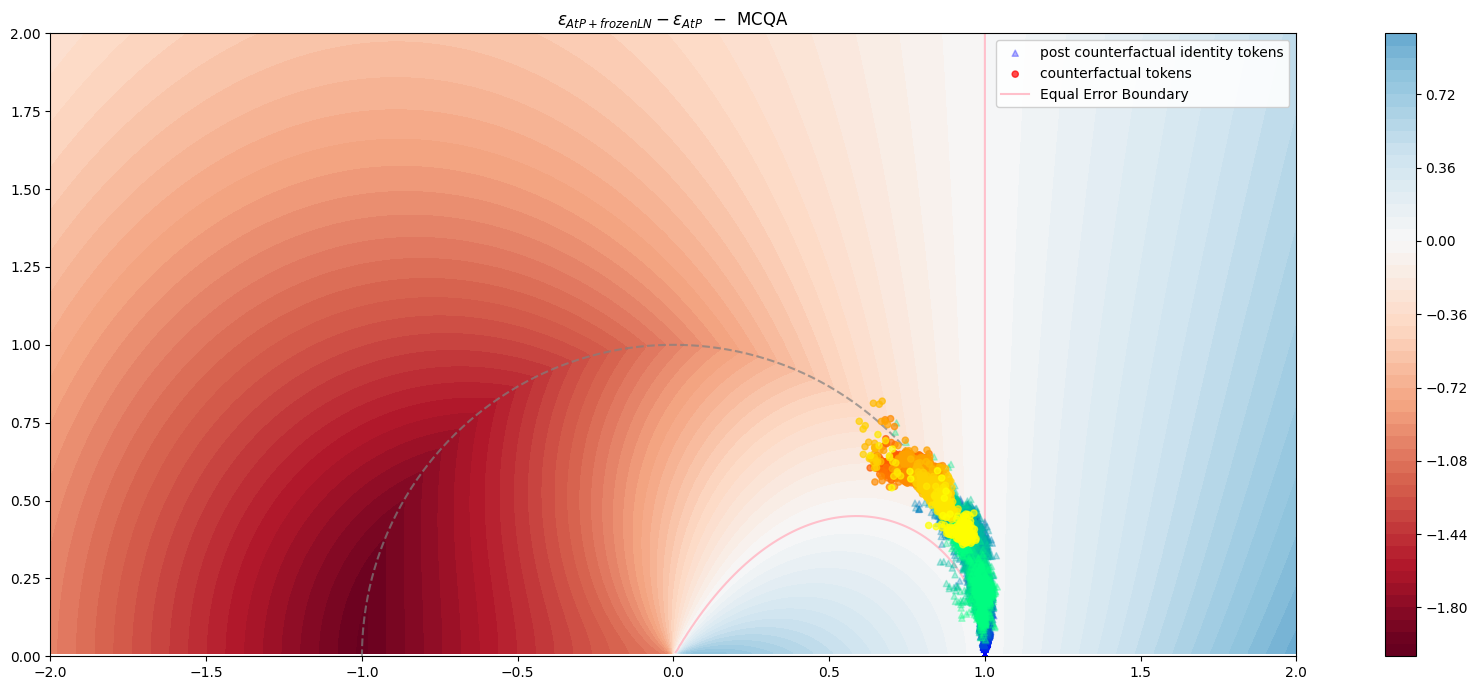